In [2]:
#EDA - taught by ayushi 
import pandas as pd

In [3]:
df = pd.read_excel(r"C:\Users\ASUS\Desktop\DataPy\cleandata.xlsx")

In [6]:
df

,EmployeeID,Name,Age,Department,Salary,JoinDate,City,Email
0,101,Alice,25,HR,45000,2023-01-15,Kathmandu,alice@example.com
1,102,Bob,30,IT,55000,2022-05-10,Pokhara,bob@example.com
2,103,Charlie,29,Finance,60000,2021-03-12,Pokhara,charlie@example.com
3,104,Dana,35,IT,65000,2020-11-01,Lalitpur,dana@example.com
4,105,Puja,35,IT,60000,2020-11-01,Lalitpur,puja@example.com
5,106,Maya,42,HR,52000,2019-07-20,Bhaktapur,eva@example.com
6,107,Frank,45,Sales,48000,2024-02-30,Biratnagar,frank@example.com
7,108,Grace,31,Marketing,70000,2022-08-18,Kathmandu,grace@example.com
8,109,Henry,28,IT,58000,2023-04-05,Pokhara,henry@example.com
9,110,Ivy,27,Finance,61000,2023-06-25,Kathmandu,ivy@example.com


In [7]:
df.dtypes

EmployeeID     int64
Name          object
Age            int64
Department    object
Salary         int64
JoinDate      object
City          object
Email         object
dtype: object

In [8]:
df.shape

(10, 8)

In [ ]:
#Univariate Analysis


In [4]:
numeric_cols = ['Age', 'Salary']

summary = df[numeric_cols].describe().T    #T  is transpose
summary['median'] = df [numeric_cols].median()
summary['skewness'] = df[numeric_cols].skew()
print("Numeric Summary Statistics:\n")
summary

Numeric Summary Statistics:



,count,mean,std,min,25%,50%,75%,max,median,skewness
Age,10.0,32.7,6.549809,25.0,28.25,30.5,35.0,45.0,30.5,0.923709
Salary,10.0,57400.0,7604.092465,45000.0,52750.00,59000.0,60750.0,70000.0,59000.0,-0.122284


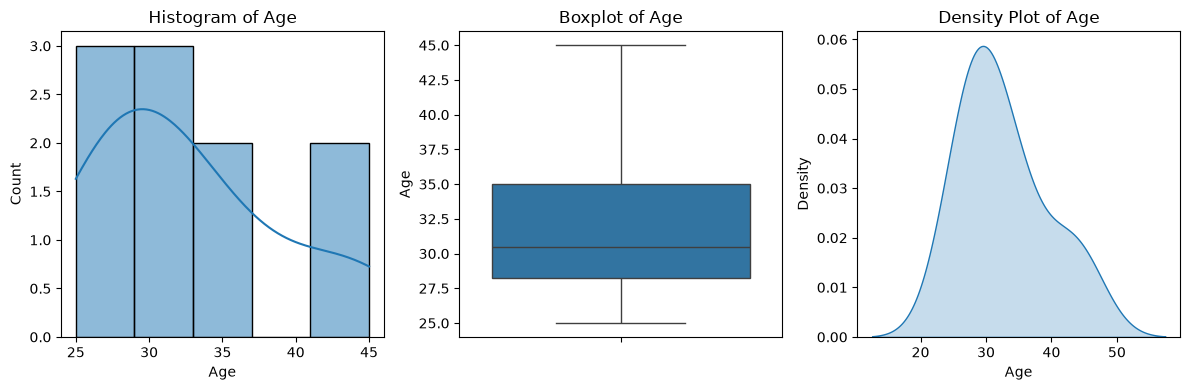

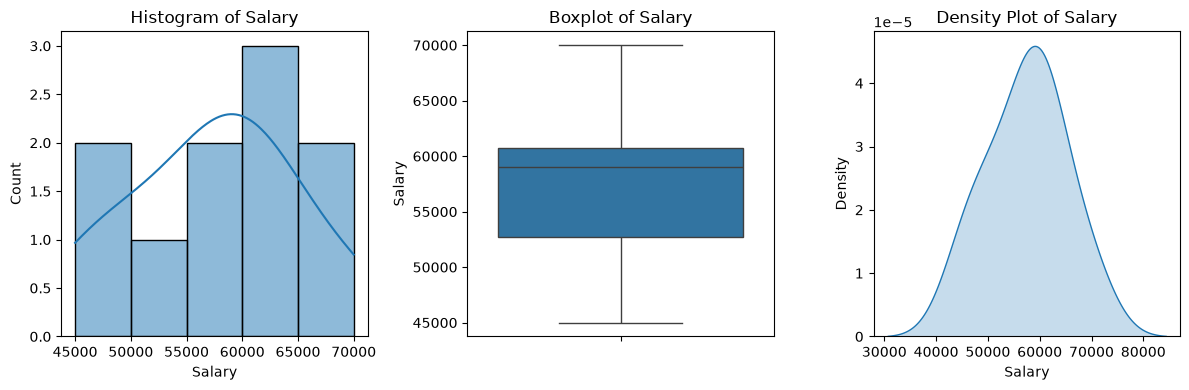

In [5]:
#histogram,boxplot, density plot for numerical col
import matplotlib.pyplot as plt
import seaborn as sns

for col in numeric_cols:
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')

    plt.subplot(1,3,2)
    sns.boxplot(y =df[col])
    plt.title(f'Boxplot of {col}')

    plt.subplot(1,3,3)
    sns.kdeplot(df[col], fill=True)
    plt.title(f'Density Plot of {col}')

    plt.tight_layout()
    plt.show()


 Frequency counts for Department:
 Department
IT           4
HR           2
Finance      2
Sales        1
Marketing    1
Name: count, dtype: int64

 Frequency counts for City:
 City
Kathmandu     3
Pokhara       3
Lalitpur      2
Bhaktapur     1
Biratnagar    1
Name: count, dtype: int64


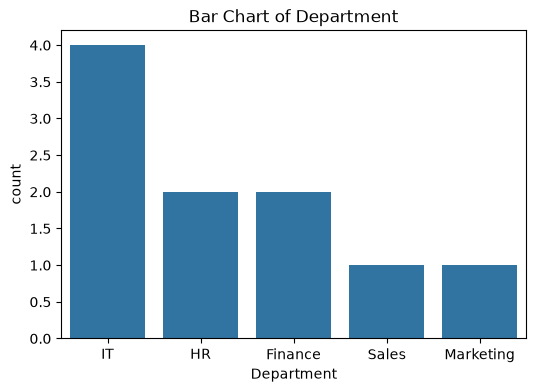

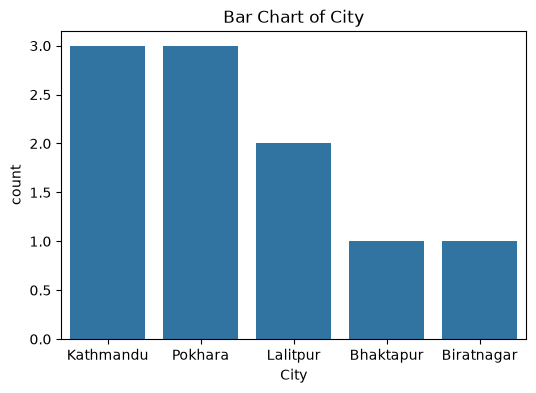

In [6]:
#Frequnecy count for categorical columns

cat_cols = ['Department', 'City']

for index, col in enumerate(cat_cols):
    print(f"\n Frequency counts for {col}:\n", df[col].value_counts())
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.title(f'Bar Chart of {col}')
    plt.show
    

In [8]:
df['JoinDate'] = pd.to_datetime(df['JoinDate'], errors='coerce')

In [10]:
df.loc[df['EmployeeID'] == 107, 'JoinDate'] = '2024-02-29'
df['JoinDate'] = pd.to_datetime(df['JoinDate'])

In [11]:
print(df[df['JoinDate'].isna()])

Empty DataFrame
Columns: [EmployeeID, Name, Age, Department, Salary, JoinDate, City, Email]
Index: []



Date Range for JoinDate: 2019-07-20 00:00:00 to 2024-02-29 00:00:00
Time span: 1685 days


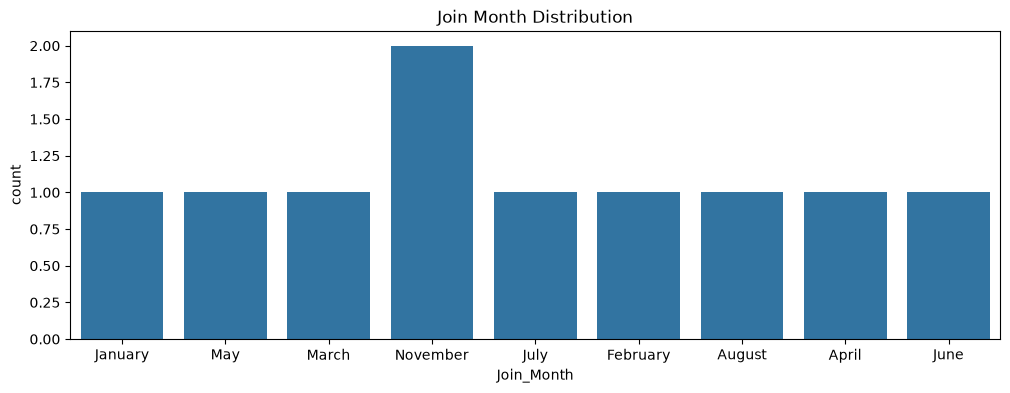

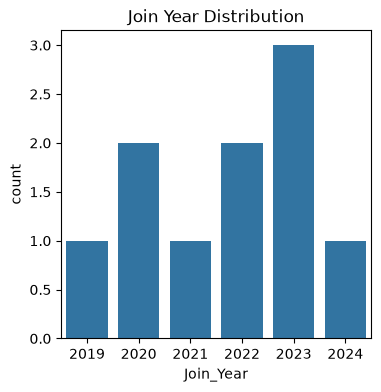

In [12]:
#same code for eda

date_cols = ['JoinDate']

# Date range
for col in date_cols:
    print(f"\nDate Range for {col}: {df[col].min()} to {df[col].max()}")
    print(f"Time span: {(df[col].max() - df[col].min()).days} days")

# Month distribution
plt.figure(figsize=(12, 4))
df['Join_Month'] = df['JoinDate'].dt.month_name()
sns.countplot(x='Join_Month', data=df)
plt.title("Join Month Distribution")
plt.show()

# Year distribution
plt.figure(figsize=(4, 4))
df['Join_Year'] = df['JoinDate'].dt.year
sns.countplot(x='Join_Year', data=df)
plt.title("Join Year Distribution")
plt.show()

In [13]:
def time_granularity(series):
    diffs = series.sort_values().diff().dropna().dt.days
    return diffs.describe()

In [14]:
time_granularity(df['JoinDate'])   #difference

count      9.000000
mean     187.222222
std      161.952754
min        0.000000
25%       81.000000
50%      131.000000
75%      249.000000
max      470.000000
Name: JoinDate, dtype: float64

In [16]:
df['JoinDate'].sort_values().diff().value_counts()  #gap betn days

JoinDate
470 days    1
0 days      1
131 days    1
424 days    1
100 days    1
150 days    1
80 days     1
81 days     1
249 days    1
Name: count, dtype: int64

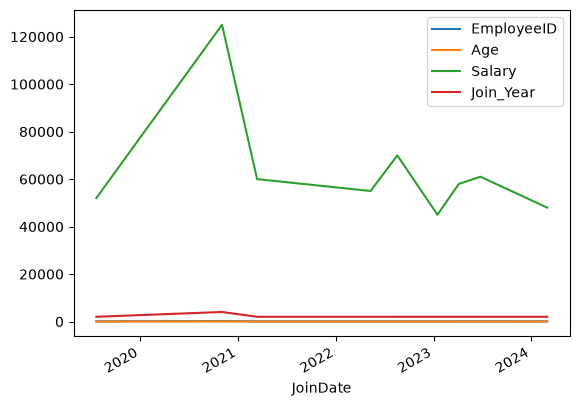

In [18]:
df.groupby('JoinDate').sum().plot()
plt.show()

In [23]:
#decompose
from statsmodels.tsa.seasonal import seasonal_decompose


In [24]:
df['JoinDate'] = pd.to_datetime(df['JoinDate'], errors='coerce')
df = df.dropna(subset=['JoinDate'])
df = df.set_index('JoinDate').sort_index()

daily = df['EmployeeID'].resample('D').count()

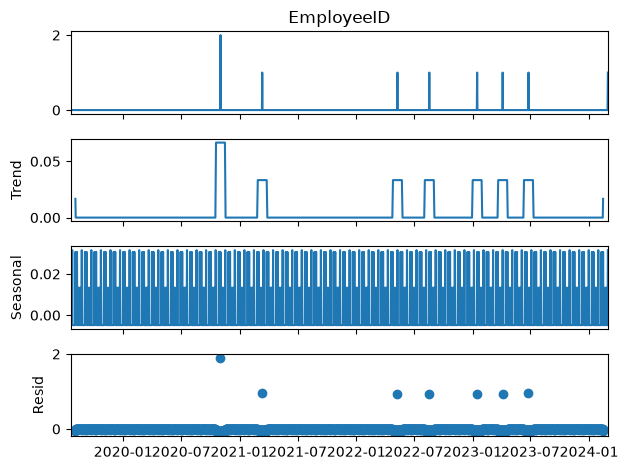

In [25]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(daily, model='additive', period=30)
result.plot()
plt.show()

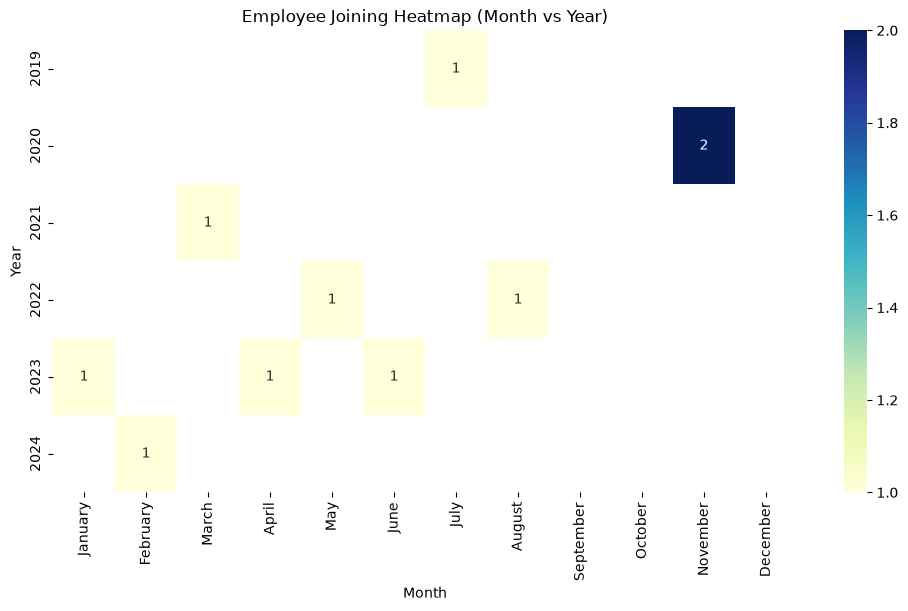

In [31]:
#heatmap hourly per day

# Create pivot table: Year vs Month
heatmap_data = df.pivot_table(
    index='Join_Year',
    columns='Join_Month',
    values='EmployeeID',
    aggfunc='count'
)

# Order months correctly (important fix)
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

heatmap_data = heatmap_data.reindex(columns=month_order)

# Plot
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=True, fmt='.0f')

plt.title('Employee Joining Heatmap (Month vs Year)')
plt.xlabel('Month')
plt.ylabel('Year')
plt.show()

In [30]:
print(df.columns.tolist())

['EmployeeID', 'Name', 'Age', 'Department', 'Salary', 'City', 'Email', 'Join_Month', 'Join_Year']
